In [5]:
# autoreload magic:
%load_ext autoreload
%autoreload 2

# imports
import copy
import glob
import numpy as np
import os
import time
import yaml
import matplotlib.pyplot as plt
import matplotlib as mpl

from NNMFit.utilities import load_pickle
from NNMFit.utilities import PseudoexpHandler

import unifigs
from unifigs.figures import SinglePlot
from unifigs import ScanPlotter

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
plotting_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/debug_bdt/gof"
os.system(f"mkdir -p {plotting_path}")

0

In [7]:
ScanPlotter()

In [8]:
# plot all param distributions just for the lulz

parameter_plot_config = {
    'gamma_astro':
        {
            'color': '#bcbd22',
            'label': r'$gamma$',
            'linestyle': '-.',
            'ylims': [0, 40],
            'xlims': [2.2, 3.5]
        },
    'astro_norm':
        {
            'color': '#bcbd22',
            'label': r'$phi_0$',
            'linestyle': '-.',
            'ylims': [0, 40],
            'xlims': [1.2, 3.2]
        },
    'CR_grad':
        {
            'color': '#bcbd22',
            'label': 'CR Model Interp.',
            'linestyle': '-.',
            'ylims': [0, 40],
            'xlims': [-1, 2]
        },
    'delta_gamma':
        {
            'color': '#ff7f0e',
            'label': 'CR $\\Delta \\gamma$',
            'linestyle': '-.',
            'ylims': [0, 10],
            'xlims': [-0.15, 0.15]
        },
    'conv_norm':
        {
            'color': 'royalblue',
            'label': '$\\Phi_{\\mathrm{Conventional}}$',
            'linestyle': '-',
            'ylims': [0, 40],
            'xlims': [0, 1.5]
        },
    'muongun_norm':
        {
            'color': 'xkcd:taupe',
            'label': '$\\Phi_{\\mu}$',
            'linestyle': '-.',
            'ylims': [0, 30],
            'xlims': [0.0, 2.0]
        },
    'prompt_norm':
        {
            'color': 'turquoise',
            'label': '$\\Phi_{\\mathrm{Prompt}}$',
            'linestyle': '-.',
            'ylims': [0, 10],
            'xlims': [0, 6]
        },
    'barr_h':
        {
            'color': 'firebrick',
            'label': 'Barr $H$',
            'linestyle': ':',
            'ylims': [0, 5],
            'xlims': [-0.12, 0.12]
        },
    'barr_w':
        {
            'color': 'firebrick',
            'label': 'Barr $W$',
            'linestyle': '--',
            'ylims': [0, 10],
            'xlims': [-0.6, 0.6]
        },
    'barr_y':
        {
            'color': 'firebrick',
            'label': 'Barr $Y$',
            'linestyle': '-.',
            'ylims': [0, 10],
            'xlims': [-0.61, 0.61]
        },
    'barr_z':
        {
            'color': 'firebrick',
            'label': 'Barr $Z$',
            'linestyle': '-',
            'ylims': [0, 10],
            'xlims': [-0.3, 0.2]
        },
    'dom_eff':
        {
            'color': 'forestgreen',
            'label': 'Opt. Efficiency',
            'linestyle': ':',
            'ylims': [0, 50],
            'xlims': [0.9, 1.1]
        },
    'ice_abs':
        {
            'color': 'forestgreen',
            'label': 'Ice Absorption',
            'linestyle': '--',
            'ylims': [0, 10],
            'xlims': [0.9, 1.1]
        },
    'ice_crystal':
        {
            'color': 'black',
            'label': 'Crystal density parameter',
            'linestyle': '--',
            'ylims': [0, 10],
            'xlims': [0.8, 1.2]
        },
    'ice_holep0':
        {
            'color': 'forestgreen',
            'label': 'Ice Hole $p_0$',
            'linestyle': '-',
            'ylims': [0, 500],
            'xlims': [-0.5, 0.7]
        },
    'ice_holep1':
        {
            'color': 'forestgreen',
            'label': 'Ice Hole $p_1$',
            'linestyle': ':',
            'ylims': [0, 200],
            'xlims': [-0.12, -0.03]
        },
    'ice_scat':
        {
            'color': 'forestgreen',
            'label': 'Ice Scattering',
            'linestyle': '-.',
            'ylims': [0, 40],
            'xlims': [0.9, 1.1]
        },
    'llh':
        {
            'color': 'black',
            'label': '$-\\log(\\mathcal{L})$',
            'linestyle': '-',
            'ylims': [0, 10]
        }
}

In [25]:
pse_path_first    = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/unblind/step1_hese_flux/pse/force_full_3_nlight_20"
pse_path_bdt      = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/unblind/step1_hese_flux/pse_debug_bdt_2"
pse_path_reproduce = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/unblind/step1_hese_flux/pse_debug_bdt_reproduce"
saturated_path    = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/debug_bdt/saturated_final"

scans = {
    # first iteration, buggy gradient, mc, wrong muon template
    "first_iteration":
        f"{pse_path_first}/pse_hese_spectrum_bestfit_13year_n500_seeded",

    # problems should be fixed, stepwise
    "start":  # reproduce first iteration
        f"{pse_path_reproduce}/start",
    "update_grad_mc":  # update gradient and mc datasets
        f"{pse_path_reproduce}/update_grad_mc",
    "update_grad_mc_asr":  # active string requirement, small change livetime
        f"{pse_path_reproduce}/update_grad_mc_asr",
    "update_grad_mc_asr_muon":  # new muon template
        f"{pse_path_reproduce}/update_grad_mc_asr_muon",

    # different bdt models
    "FinalTopology":
        f"{pse_path_bdt}/FinalTopology_double_energy_length_binning/pse_FinalTopology_double_energy_length_binning_n500_seeded",
    "11features":
        f"{pse_path_bdt}/mcd-simpletopology_flux-hese_feat-11features/bdt1_0.333333_bdt2_0.366667_length_10/pse_mcd-simpletopology_flux-hese_feat-11features_n500_seeded/",
    "11features_plus_rloglmilli":
        f"{pse_path_bdt}/mcd-simpletopology_flux-hese_feat-11features_plus_rloglmilli/bdt1_0.333333_bdt2_0.366667_length_10/pse_mcd-simpletopology_flux-hese_feat-11features_plus_rloglmilli_n500_seeded/",
    "11features_plus_evtgen":
        f"{pse_path_bdt}/mcd-simpletopology_flux-hese_feat-11features_plus_evtgen/bdt1_0.333333_bdt2_0.366667_length_10/pse_mcd-simpletopology_flux-hese_feat-11features_plus_evtgen_n500_seeded/",
    "11features_plus_econf":
        f"{pse_path_bdt}/mcd-simpletopology_flux-hese_feat-11features_plus_econf/bdt1_0.333333_bdt2_0.366667_length_10/pse_mcd-simpletopology_flux-hese_feat-11features_plus_econf_n500_seeded/",
    "11features_plus_rloglmilli_econf_evtgen":
        f"{pse_path_bdt}/mcd-simpletopology_flux-hese_feat-11features_plus_rloglmilli_econf_evtgen/bdt1_0.333333_bdt2_0.366667_length_10/pse_mcd-simpletopology_flux-hese_feat-11features_plus_rloglmilli_econf_evtgen_n500_seeded/",
}

names = list(scans.keys())

mask_unsuccessfull = True

scan_hdls = {}

for name in names:

    print(20*"-")
    print(name)
    print(scans[name])

    scan_hdls[name] = PseudoexpHandler(
        scans[name],
        force_read=True,
        mask_unsuccessful=mask_unsuccessfull,
        sat_llh_calculation_type="poisson",
    )


--------------------
first_iteration
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/unblind/step1_hese_flux/pse/force_full_3_nlight_20/pse_hese_spectrum_bestfit_13year_n500_seeded


/home/pfuerst/software/icecube/NNMFit/NNMFit/utilities/result_handlers.py:201: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['CR_grad', 'astro_norm', 'barr_h', 'barr_w', 'barr_y', 'barr_z',
       'conv_norm', 'delta_gamma', 'dom_eff', 'fit_success', 'gamma_astro',
       'ice_abs', 'ice_crystal', 'ice_holep0', 'ice_holep1', 'ice_scat', 'llh',
       'muongun_norm', 'prompt_norm', 'pseudoexp_seed'],
      dtype='object')]

  df.to_hdf(self.scan_result_file, key="scans")
/home/pfuerst/software/icecube/NNMFit/NNMFit/utilities/result_handlers.py:443: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block1_values] [items->Index(['CR_grad', 'astro_norm', 'barr_h', 'barr_w', 'barr_y', 'barr_z',
       'conv_norm', 'delta_gamma', 'dom_eff', '

--------------------
start
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/unblind/step1_hese_flux/pse_debug_bdt_reproduce/start


/home/pfuerst/software/icecube/NNMFit/NNMFit/utilities/result_handlers.py:201: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['CR_grad', 'astro_norm', 'barr_h', 'barr_w', 'barr_y', 'barr_z',
       'conv_norm', 'delta_gamma', 'dom_eff', 'fit_success', 'gamma_astro',
       'ice_abs', 'ice_crystal', 'ice_holep0', 'ice_holep1', 'ice_scat', 'llh',
       'muongun_norm', 'prompt_norm', 'pseudoexp_seed'],
      dtype='object')]

  df.to_hdf(self.scan_result_file, key="scans")
/home/pfuerst/software/icecube/NNMFit/NNMFit/utilities/result_handlers.py:443: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block1_values] [items->Index(['CR_grad', 'astro_norm', 'barr_h', 'barr_w', 'barr_y', 'barr_z',
       'conv_norm', 'delta_gamma', 'dom_eff', '

--------------------
update_grad_mc
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/unblind/step1_hese_flux/pse_debug_bdt_reproduce/update_grad_mc


...

/home/pfuerst/software/icecube/NNMFit/NNMFit/utilities/result_handlers.py:201: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['CR_grad', 'astro_norm', 'barr_h', 'barr_w', 'barr_y', 'barr_z',
       'conv_norm', 'delta_gamma', 'dom_eff', 'fit_success', 'gamma_astro',
       'ice_abs', 'ice_crystal', 'ice_holep0', 'ice_holep1', 'ice_scat', 'llh',
       'muongun_norm', 'prompt_norm', 'pseudoexp_seed'],
      dtype='object')]

  df.to_hdf(self.scan_result_file, key="scans")
/home/pfuerst/software/icecube/NNMFit/NNMFit/utilities/result_handlers.py:443: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block1_values] [items->Index(['CR_grad', 'astro_norm', 'barr_h', 'barr_w', 'barr_y', 'barr_z',
       'conv_norm', 'delta_gamma', 'dom_eff', '

--------------------
11features_plus_econf
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/unblind/step1_hese_flux/pse_debug_bdt_2/mcd-simpletopology_flux-hese_feat-11features_plus_econf/bdt1_0.333333_bdt2_0.366667_length_10/pse_mcd-simpletopology_flux-hese_feat-11features_plus_econf_n500_seeded/


/home/pfuerst/software/icecube/NNMFit/NNMFit/utilities/result_handlers.py:201: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['CR_grad', 'astro_norm', 'barr_h', 'barr_w', 'barr_y', 'barr_z',
       'conv_norm', 'delta_gamma', 'dom_eff', 'fit_success', 'gamma_astro',
       'ice_abs', 'ice_crystal', 'ice_holep0', 'ice_holep1', 'ice_scat', 'llh',
       'muongun_norm', 'prompt_norm', 'pseudoexp_seed'],
      dtype='object')]

  df.to_hdf(self.scan_result_file, key="scans")
/home/pfuerst/software/icecube/NNMFit/NNMFit/utilities/result_handlers.py:443: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block1_values] [items->Index(['CR_grad', 'astro_norm', 'barr_h', 'barr_w', 'barr_y', 'barr_z',
       'conv_norm', 'delta_gamma', 'dom_eff', '

--------------------
11features_plus_rloglmilli_econf_evtgen
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/unblind/step1_hese_flux/pse_debug_bdt_2/mcd-simpletopology_flux-hese_feat-11features_plus_rloglmilli_econf_evtgen/bdt1_0.333333_bdt2_0.366667_length_10/pse_mcd-simpletopology_flux-hese_feat-11features_plus_rloglmilli_econf_evtgen_n500_seeded/


/home/pfuerst/software/icecube/NNMFit/NNMFit/utilities/result_handlers.py:201: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['CR_grad', 'astro_norm', 'barr_h', 'barr_w', 'barr_y', 'barr_z',
       'conv_norm', 'delta_gamma', 'dom_eff', 'fit_success', 'gamma_astro',
       'ice_abs', 'ice_crystal', 'ice_holep0', 'ice_holep1', 'ice_scat', 'llh',
       'muongun_norm', 'prompt_norm', 'pseudoexp_seed'],
      dtype='object')]

  df.to_hdf(self.scan_result_file, key="scans")
/home/pfuerst/software/icecube/NNMFit/NNMFit/utilities/result_handlers.py:443: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block1_values] [items->Index(['CR_grad', 'astro_norm', 'barr_h', 'barr_w', 'barr_y', 'barr_z',
       'conv_norm', 'delta_gamma', 'dom_eff', '

In [26]:
# mpl color cycle
colors = mpl.rcParams['axes.prop_cycle'].by_key()['color']

# update these to 3 zenith bins
all_hdls = {}

for name in names:
    all_hdls[name] = {}
    all_hdls[name]["pseudoexp_hdl"] = scan_hdls[name]
    all_hdls[name]["pseudoexp_settings"] = {"color": colors[0],"label": name}
    all_hdls[name]["injection_points"] = scan_hdls[name].get_injected_values()

In [27]:
scanplotter = ScanPlotter.from_dict(
    all_hdls, override_parameter_plot_config=parameter_plot_config
)

In [28]:
combos = [
        [name] for name in names
]

first_iteration
['CR_grad', 'astro_norm', 'barr_h', 'barr_w', 'barr_y', 'barr_z', 'conv_norm', 'delta_gamma', 'dom_eff', 'gamma_astro', 'ice_abs', 'ice_crystal', 'ice_holep0', 'ice_holep1', 'ice_scat', 'muongun_norm', 'prompt_norm']


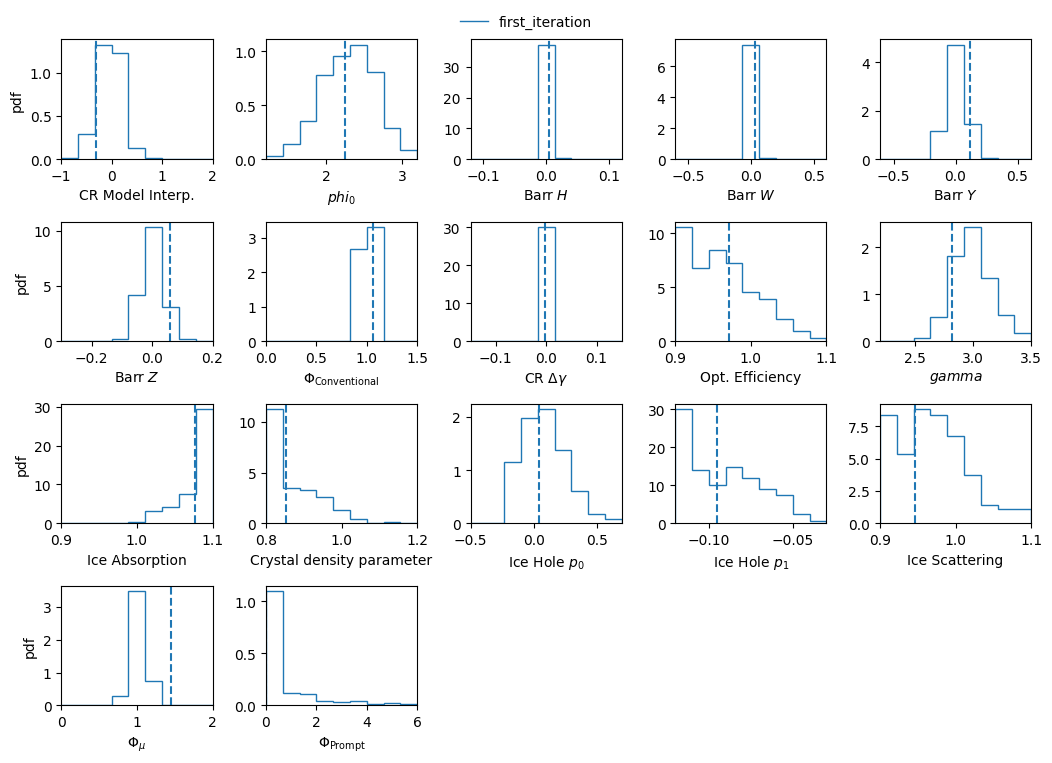

start
['CR_grad', 'astro_norm', 'barr_h', 'barr_w', 'barr_y', 'barr_z', 'conv_norm', 'delta_gamma', 'dom_eff', 'gamma_astro', 'ice_abs', 'ice_crystal', 'ice_holep0', 'ice_holep1', 'ice_scat', 'muongun_norm', 'prompt_norm']


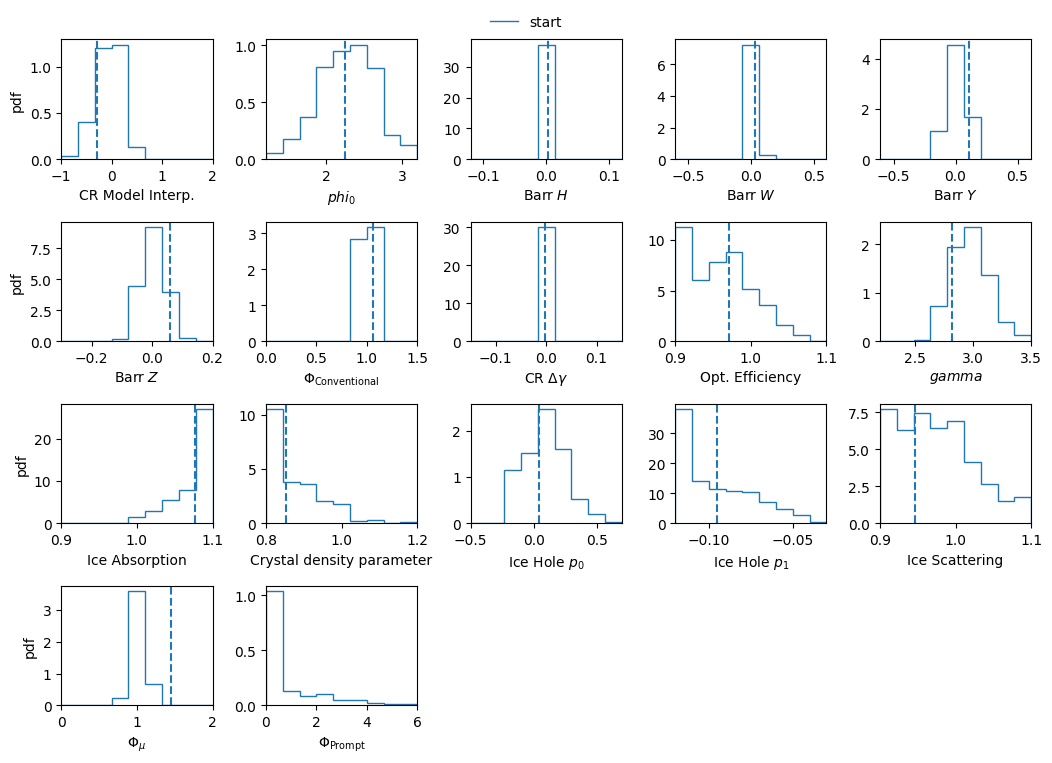

update_grad_mc
['CR_grad', 'astro_norm', 'barr_h', 'barr_w', 'barr_y', 'barr_z', 'conv_norm', 'delta_gamma', 'dom_eff', 'gamma_astro', 'ice_abs', 'ice_crystal', 'ice_holep0', 'ice_holep1', 'ice_scat', 'muongun_norm', 'prompt_norm']


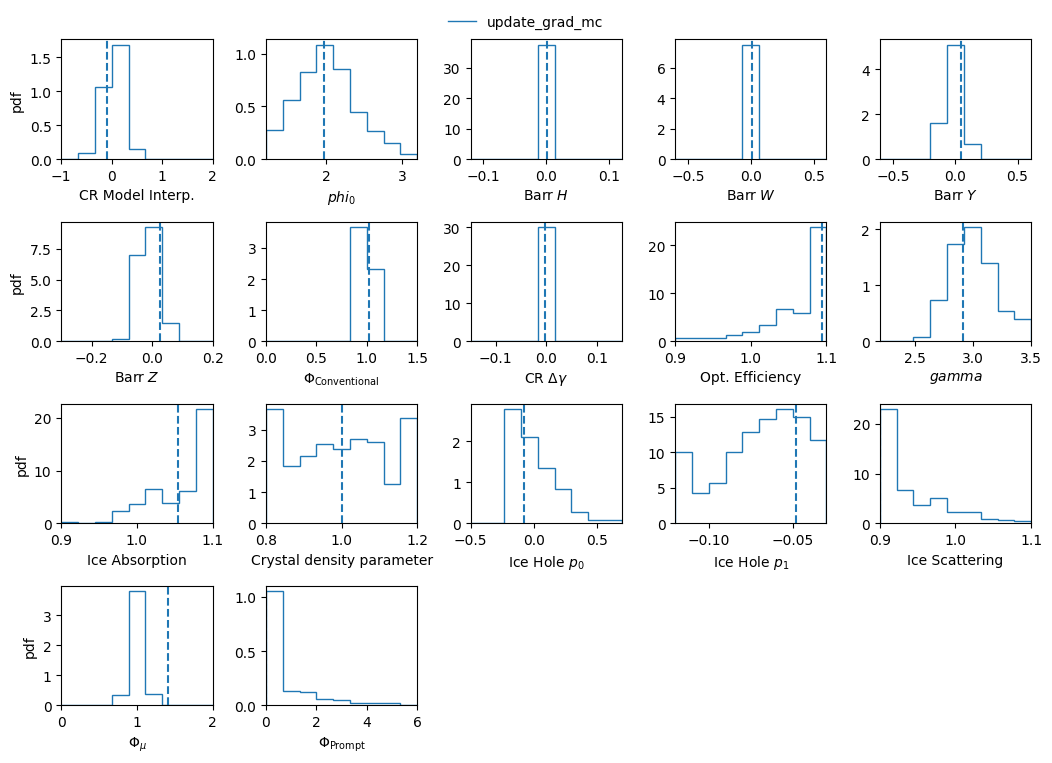

update_grad_mc_asr
['CR_grad', 'astro_norm', 'barr_h', 'barr_w', 'barr_y', 'barr_z', 'conv_norm', 'delta_gamma', 'dom_eff', 'gamma_astro', 'ice_abs', 'ice_crystal', 'ice_holep0', 'ice_holep1', 'ice_scat', 'muongun_norm', 'prompt_norm']


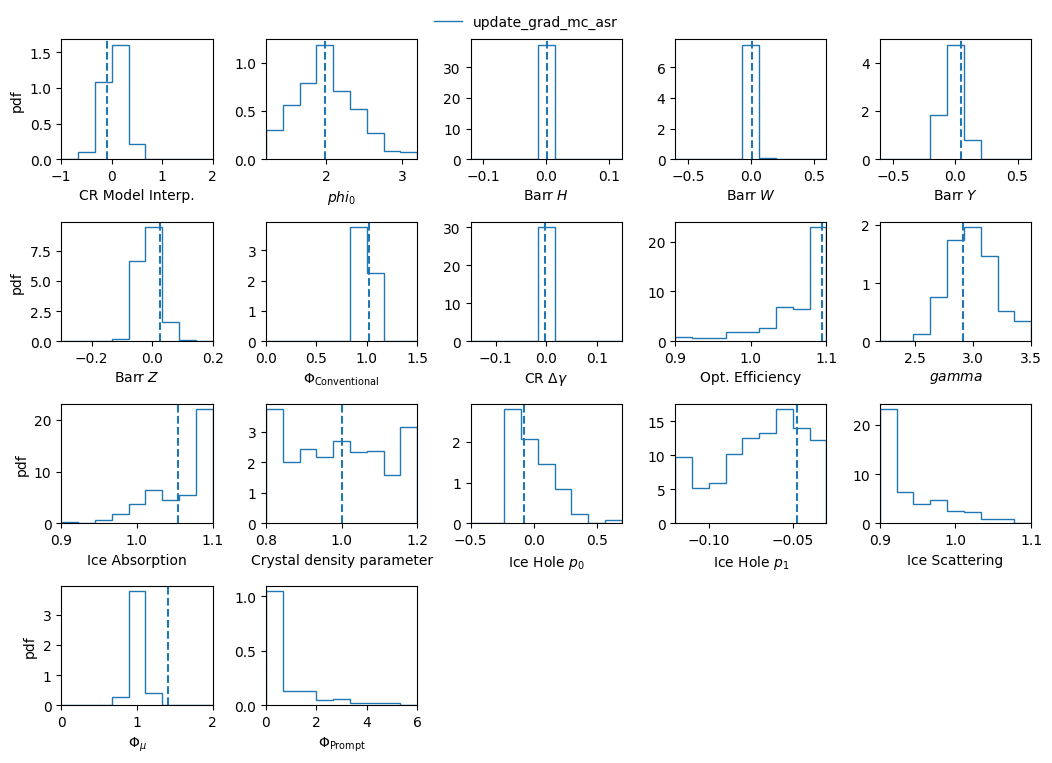

update_grad_mc_asr_muon
['CR_grad', 'astro_norm', 'barr_h', 'barr_w', 'barr_y', 'barr_z', 'conv_norm', 'delta_gamma', 'dom_eff', 'gamma_astro', 'ice_abs', 'ice_crystal', 'ice_holep0', 'ice_holep1', 'ice_scat', 'muongun_norm', 'prompt_norm']


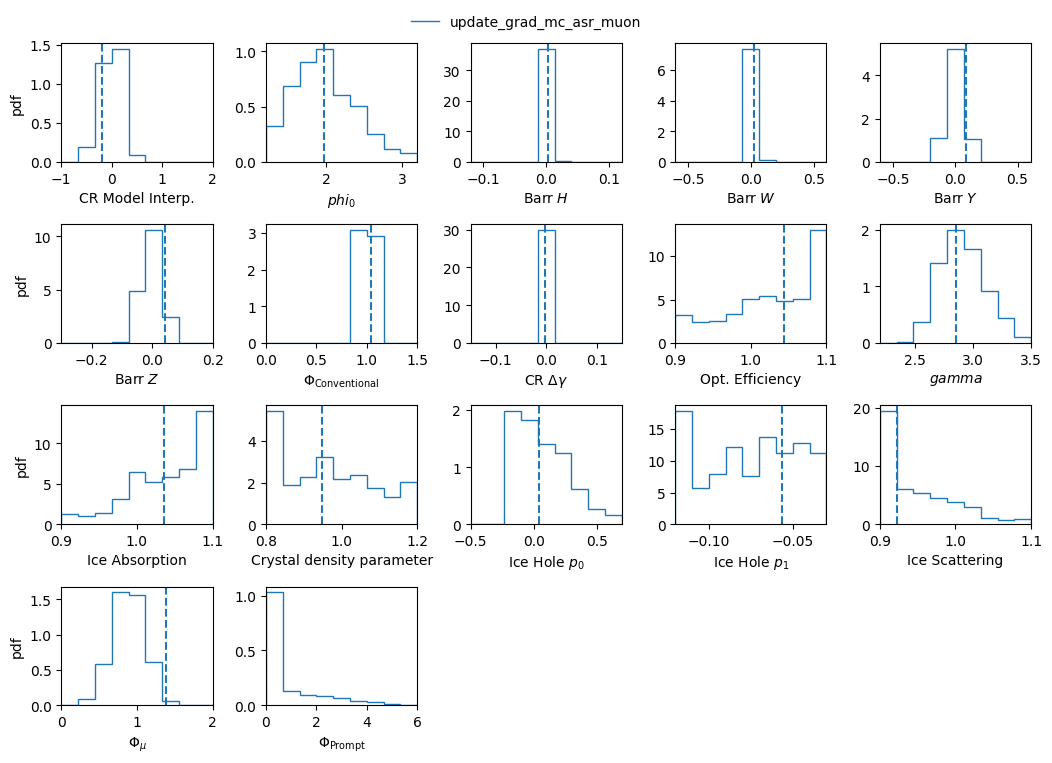

FinalTopology
['CR_grad', 'astro_norm', 'barr_h', 'barr_w', 'barr_y', 'barr_z', 'conv_norm', 'delta_gamma', 'dom_eff', 'gamma_astro', 'ice_abs', 'ice_crystal', 'ice_holep0', 'ice_holep1', 'ice_scat', 'muongun_norm', 'prompt_norm']


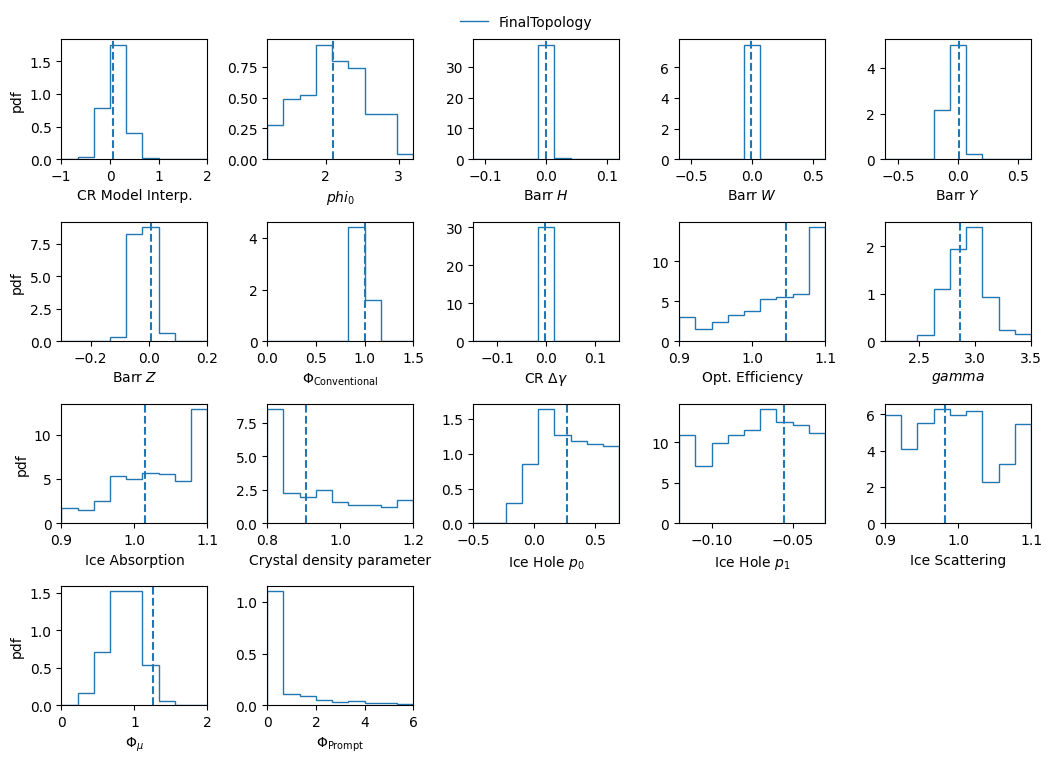

11features
['CR_grad', 'astro_norm', 'barr_h', 'barr_w', 'barr_y', 'barr_z', 'conv_norm', 'delta_gamma', 'dom_eff', 'gamma_astro', 'ice_abs', 'ice_crystal', 'ice_holep0', 'ice_holep1', 'ice_scat', 'muongun_norm', 'prompt_norm']


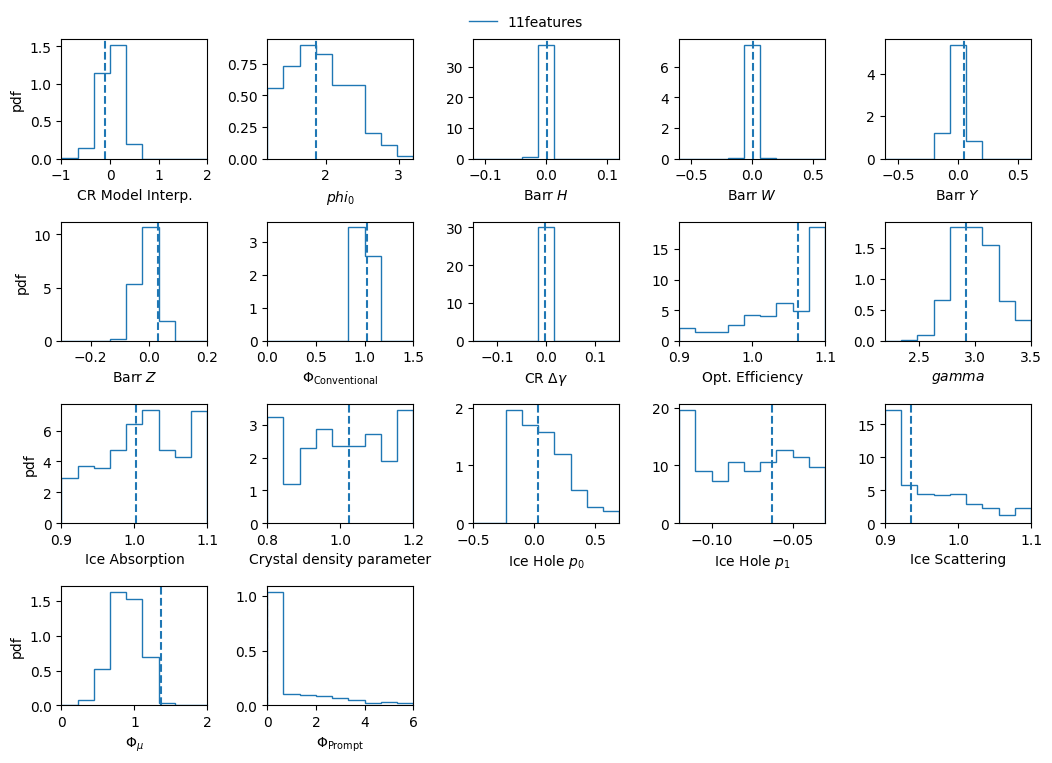

11features_plus_rloglmilli
['CR_grad', 'astro_norm', 'barr_h', 'barr_w', 'barr_y', 'barr_z', 'conv_norm', 'delta_gamma', 'dom_eff', 'gamma_astro', 'ice_abs', 'ice_crystal', 'ice_holep0', 'ice_holep1', 'ice_scat', 'muongun_norm', 'prompt_norm']


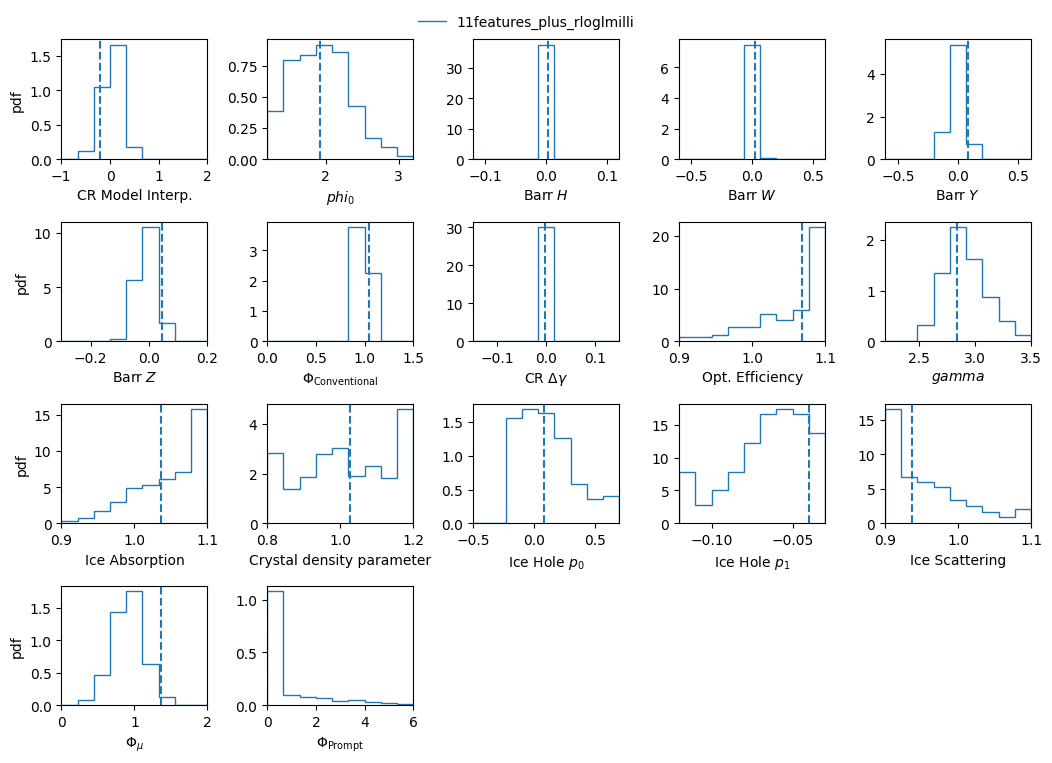

11features_plus_evtgen
['CR_grad', 'astro_norm', 'barr_h', 'barr_w', 'barr_y', 'barr_z', 'conv_norm', 'delta_gamma', 'dom_eff', 'gamma_astro', 'ice_abs', 'ice_crystal', 'ice_holep0', 'ice_holep1', 'ice_scat', 'muongun_norm', 'prompt_norm']


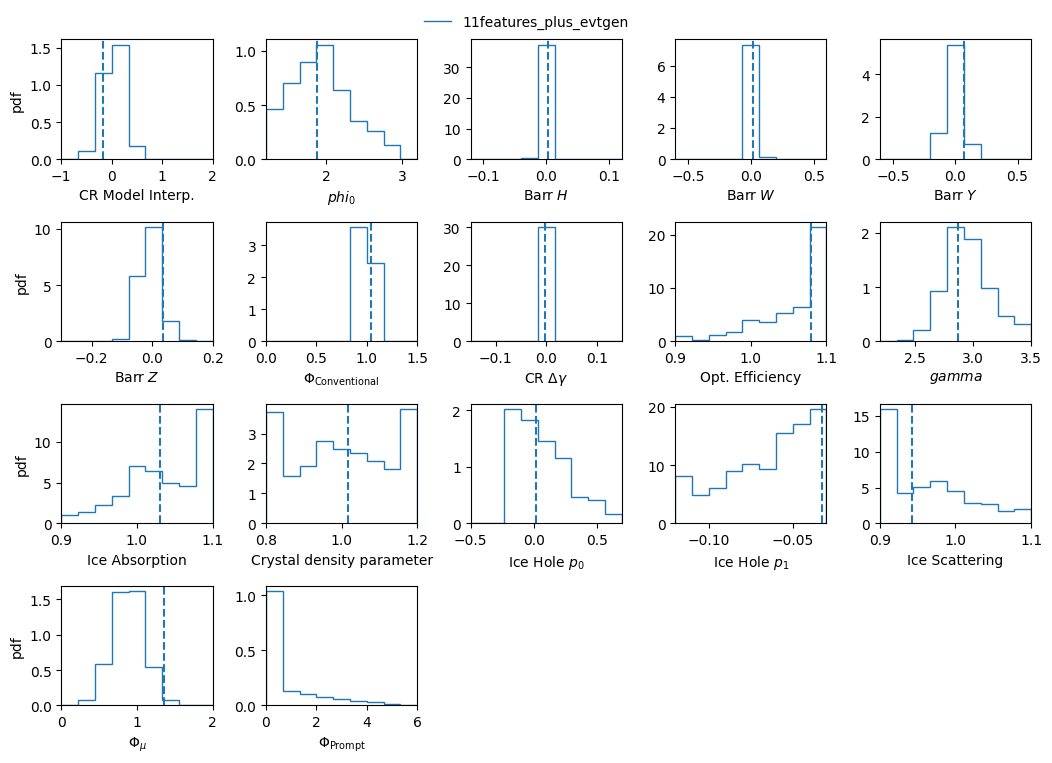

11features_plus_econf
['CR_grad', 'astro_norm', 'barr_h', 'barr_w', 'barr_y', 'barr_z', 'conv_norm', 'delta_gamma', 'dom_eff', 'gamma_astro', 'ice_abs', 'ice_crystal', 'ice_holep0', 'ice_holep1', 'ice_scat', 'muongun_norm', 'prompt_norm']


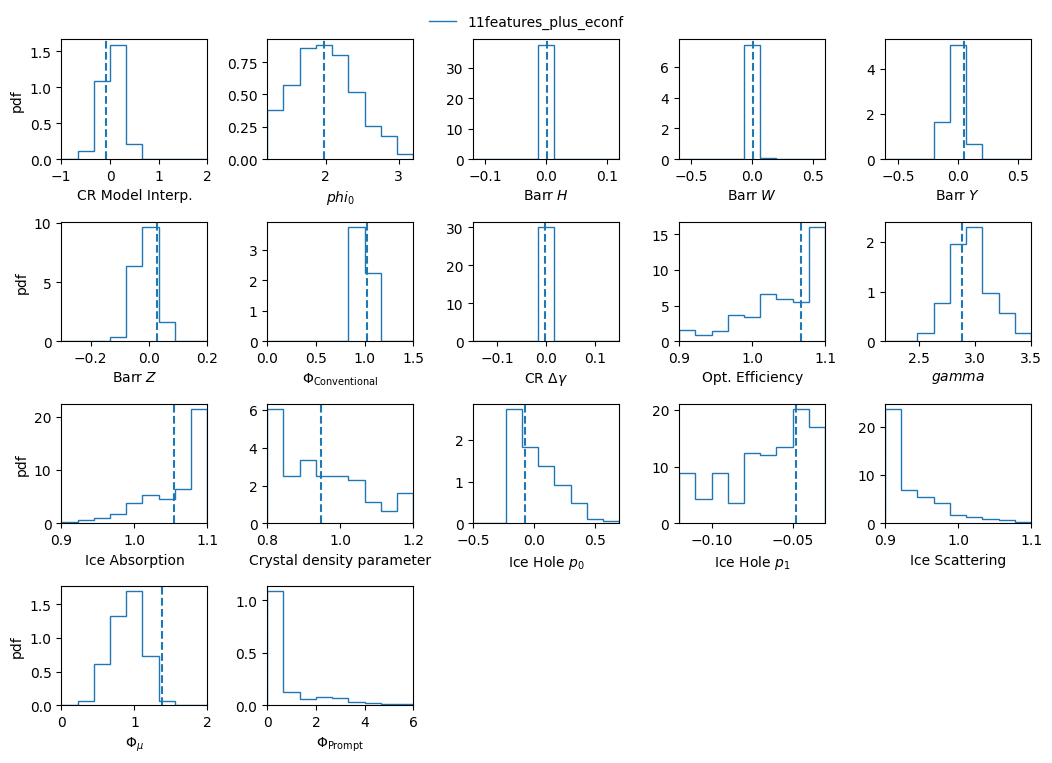

11features_plus_rloglmilli_econf_evtgen
['CR_grad', 'astro_norm', 'barr_h', 'barr_w', 'barr_y', 'barr_z', 'conv_norm', 'delta_gamma', 'dom_eff', 'gamma_astro', 'ice_abs', 'ice_crystal', 'ice_holep0', 'ice_holep1', 'ice_scat', 'muongun_norm', 'prompt_norm']


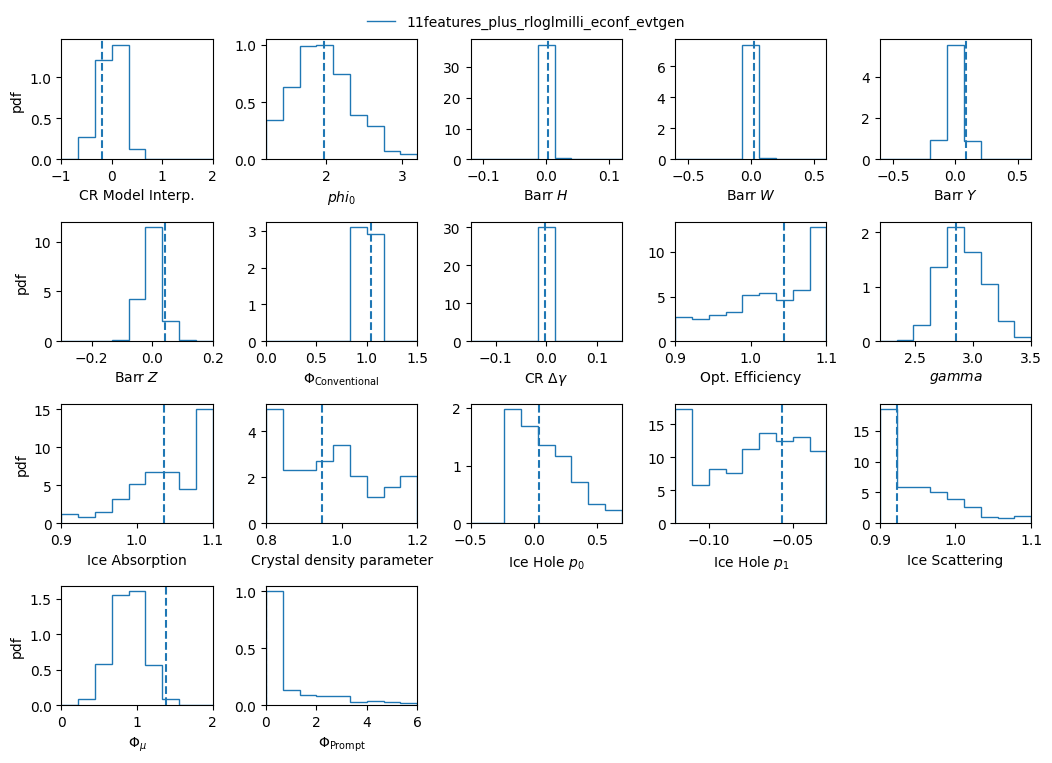

In [29]:
for combo in combos:
    print(combo[0])
    fig, handles, labels = scanplotter.plot_scan_matrix(
        scans_to_plot=combo,
        do_asimov=False,
        do_pseudoexp=True,
        # nbins=25,
        width_scale=1.9,
        height_scale=0.7,
        remove_peaks=False,
        default_ylims=False,
        plot_inject=True,
    )
    # labels = [format_label(label) for label in labels]
    # edit the hspace and wspaces between subplots:
    fig.subplots_adjust(hspace=0.25, wspace=0.3)
    plt.tight_layout()
    fig.legend(
        handles,
        labels,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.03),
        ncol=len(handles),
        frameon=False
    )
    # axes = fig.axes
    # axes[0].axvline(1.0, color='black', linestyle='--')
    plt.savefig(
        f"{plotting_path}/pse_{combo[0]}.png",
        bbox_inches='tight'
    )
    plt.show()

#### LLH Distributions

In [30]:
dfs = {}

for name in names:
    ts = 2 * (
        scan_hdls[name].get_pseudoexp_df()["llh"] -
        scan_hdls[name].get_pseudoexp_df()["sat_llh"]
    )

    # add combined ts to df:
    dfs[name] = scan_hdls[name].get_pseudoexp_df()
    dfs[name]["combined_ts"] = ts

#### LLH bestfits

In [31]:
bestfit_llh_infos = {}
for name in names:
    print(name)

    sat_file = f"{saturated_path}/{name}/SatLLH.txt"
    print(sat_file)

    with open(sat_file, "r") as f:
        llh_info = yaml.safe_load(f)
    print(llh_info)
    bestfit_ts = 2 * (llh_info["min LLH"] - llh_info["Saturated LLH"])
    if "Poisson" in name:
        # saturated llh is already substracted for Poisson
        bestfit_ts = 2 * llh_info["min LLH"]
    bestfit_llh_infos[name] = llh_info
    bestfit_llh_infos[name]['ts'] = bestfit_ts


first_iteration
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/debug_bdt/saturated_final/first_iteration/SatLLH.txt
{'Scan Path': '/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/unblind/step1_hese_flux/data_fits//force_full_3_nlight_20/nbestfit20_scan_astro_gamma_1D_10steps_round2', 'min LLH': 212.8606063267837, 'Saturated LLH': 90.96186371833632}
start
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/debug_bdt/saturated_final/start/SatLLH.txt
{'Scan Path': '/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/unblind/step1_hese_flux/data_fits_debug_bdt_reproduce//start', 'min LLH': 212.85726985147545, 'Saturated LLH': 90.96186371833632}
update_grad_mc
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/debug_bdt/saturated_final/update_grad_mc/SatLLH.txt
{'Scan Path': '/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/

{'Scan Path': '/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/unblind/step1_hese_flux/data_fits_debug_bdt_2//mcd-simpletopology_flux-hese_feat-11features/bdt1_0.333333_bdt2_0.366667_length_10/nbestfit20_scan_astro_gamma_1D_10steps', 'min LLH': 191.5157014713907, 'Saturated LLH': 87.34815807945621}
11features_plus_rloglmilli
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/debug_bdt/saturated_final/11features_plus_rloglmilli/SatLLH.txt
{'Scan Path': '/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/unblind/step1_hese_flux/data_fits_debug_bdt_2//mcd-simpletopology_flux-hese_feat-11features_plus_rloglmilli/bdt1_0.333333_bdt2_0.366667_length_10/nbestfit20_scan_astro_gamma_1D_10steps', 'min LLH': 190.96611970245408, 'Saturated LLH': 87.34815807945621}
11features_plus_evtgen
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/debug_bdt/saturated_final/11features_plus_evtgen/SatL

### Chisq distributions

first_iteration
start
update_grad_mc
update_grad_mc_asr
update_grad_mc_asr_muon
FinalTopology
11features
11features_plus_rloglmilli
11features_plus_evtgen
11features_plus_econf
11features_plus_rloglmilli_econf_evtgen


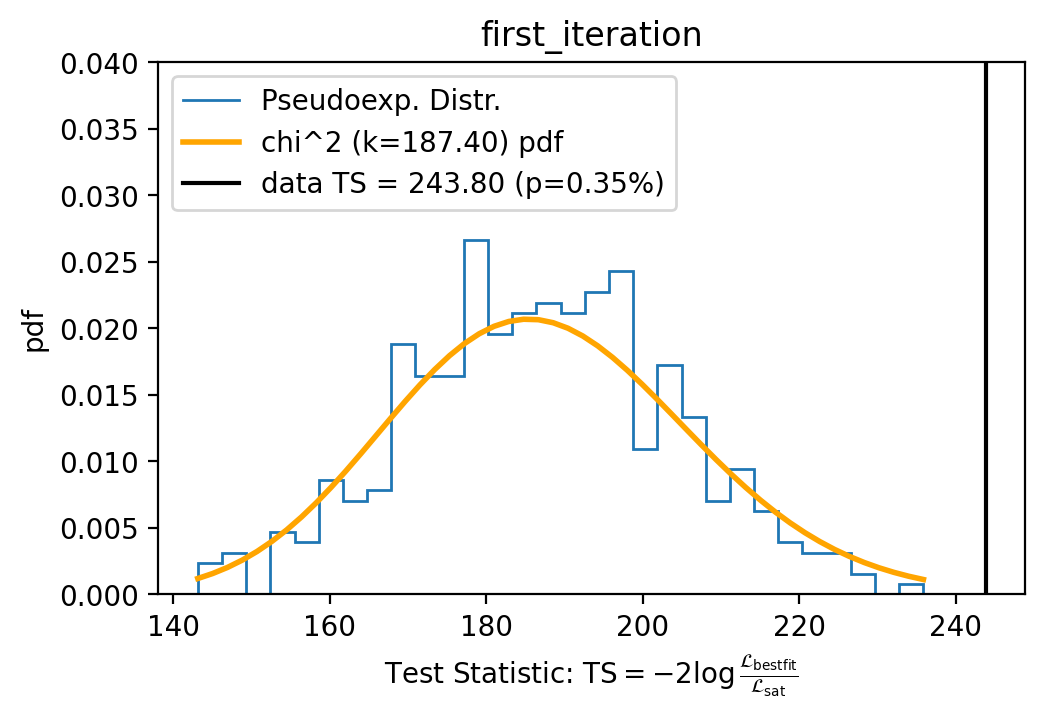

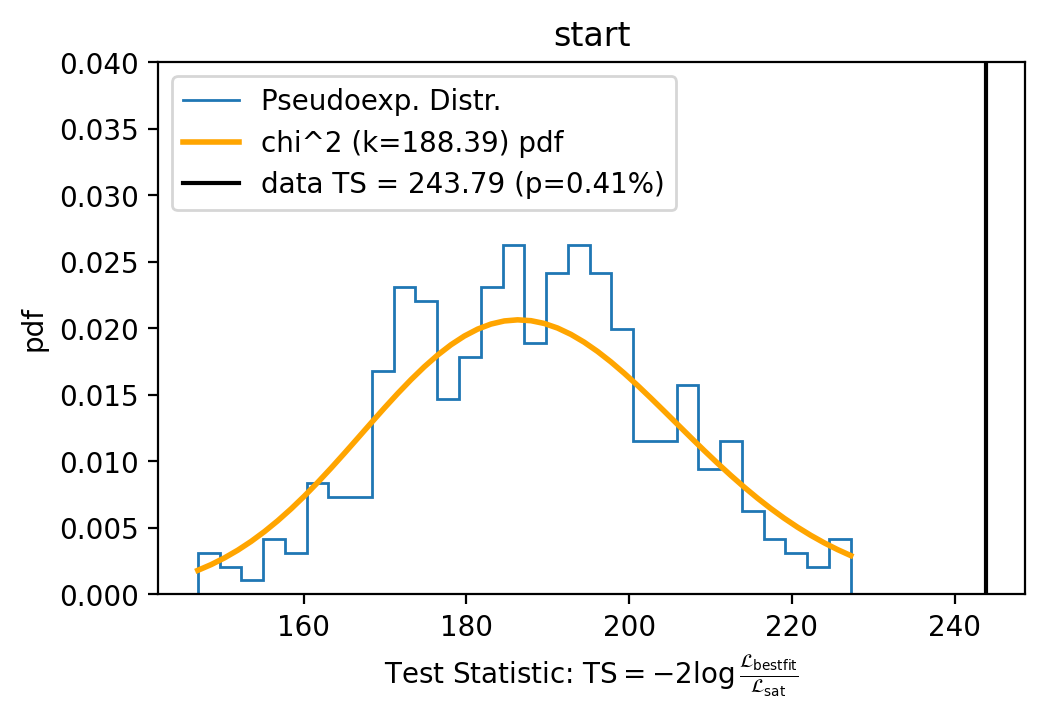

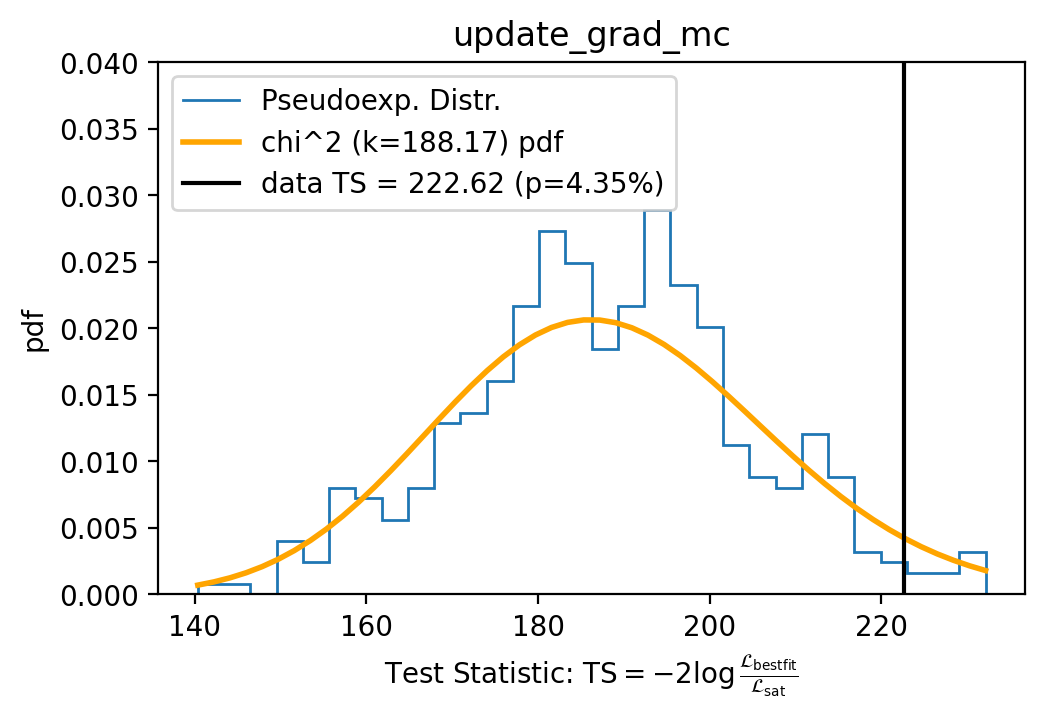

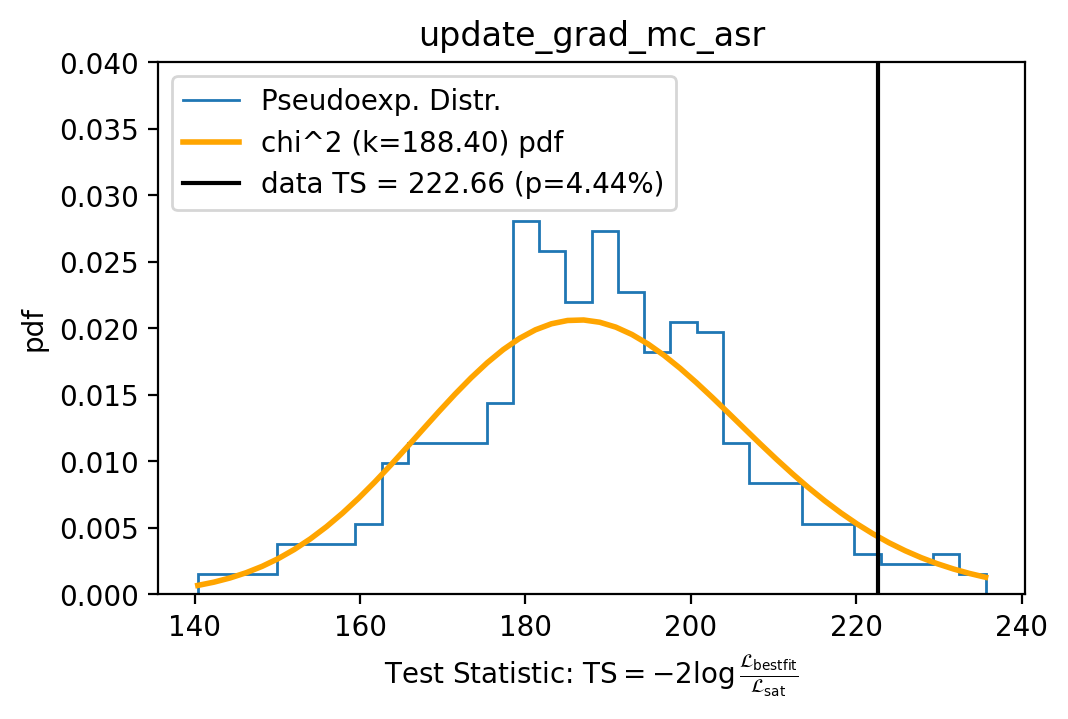

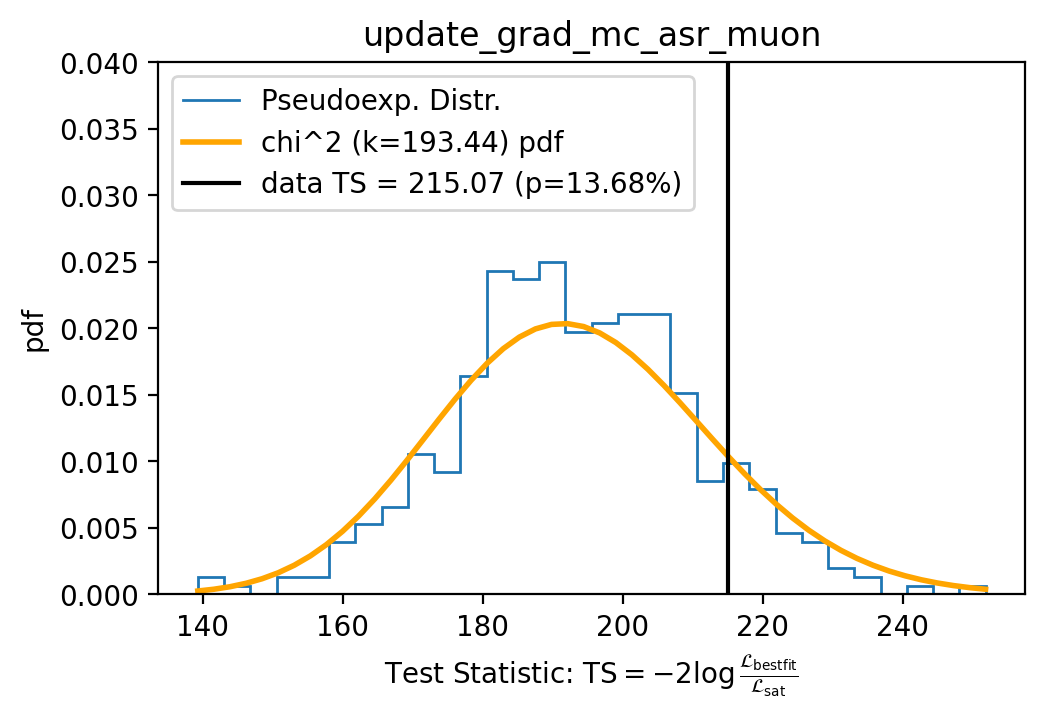

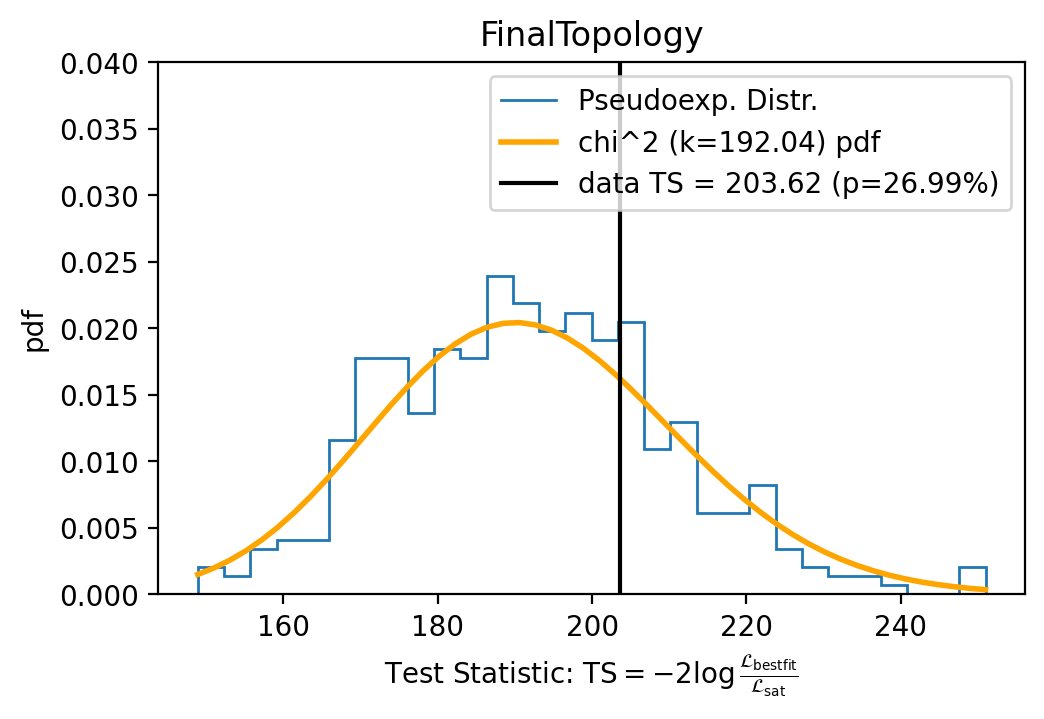

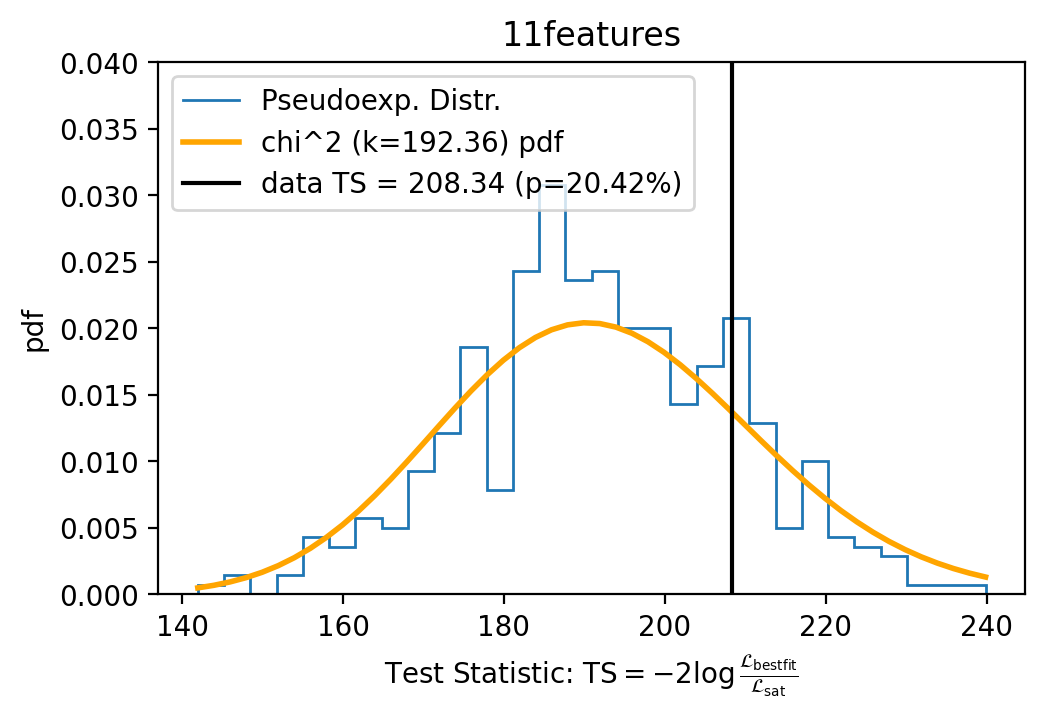

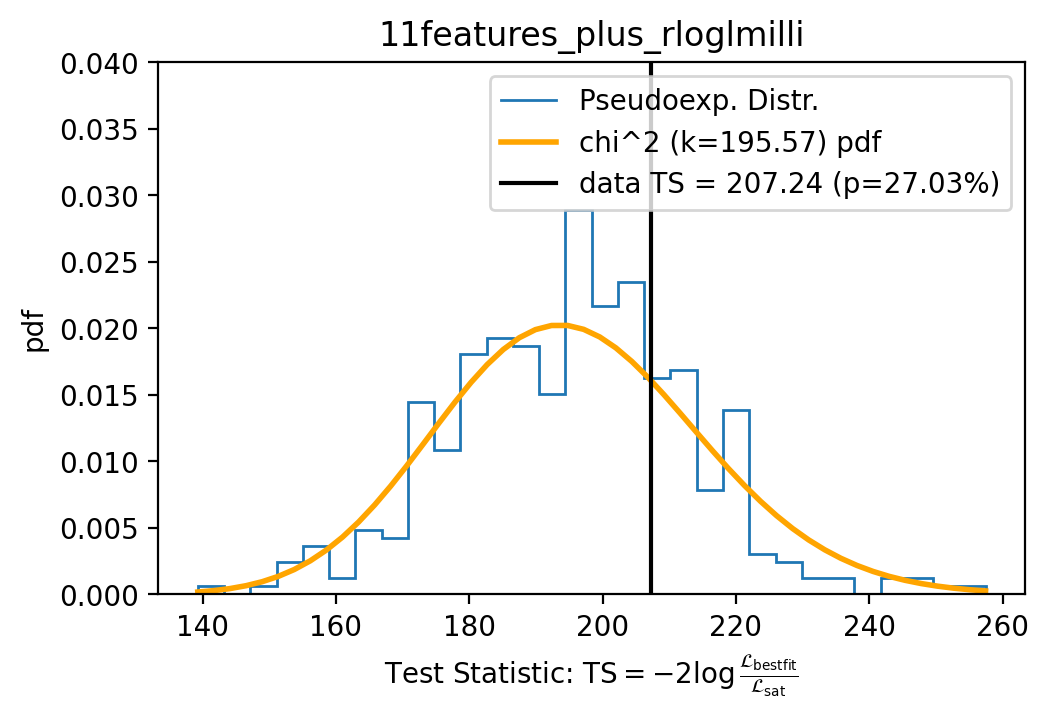

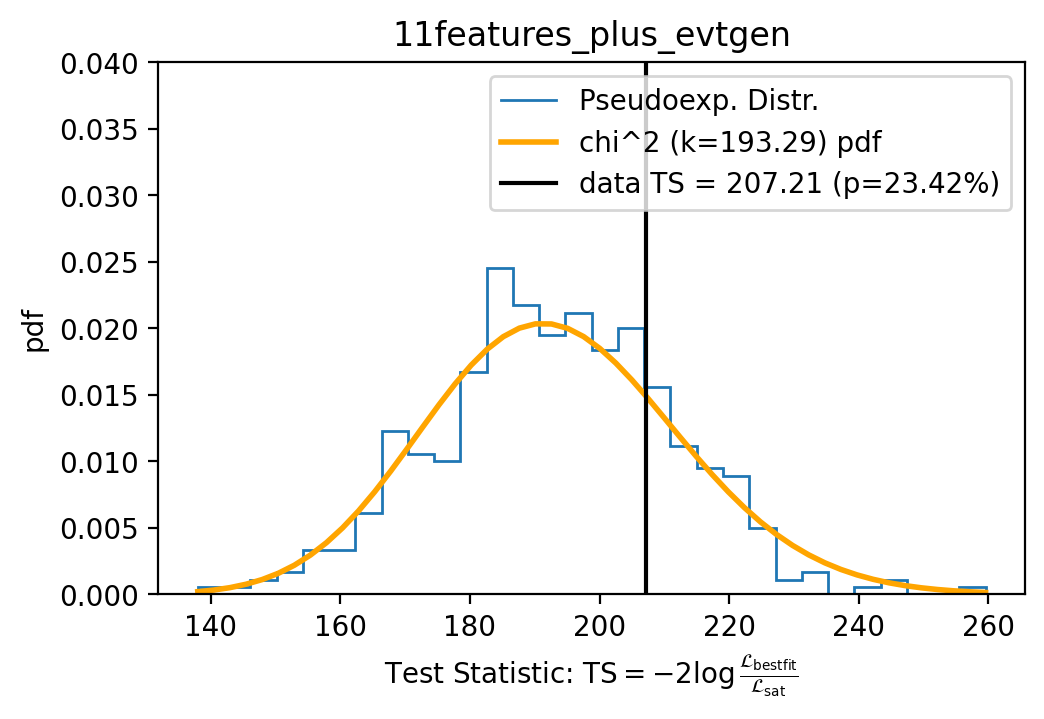

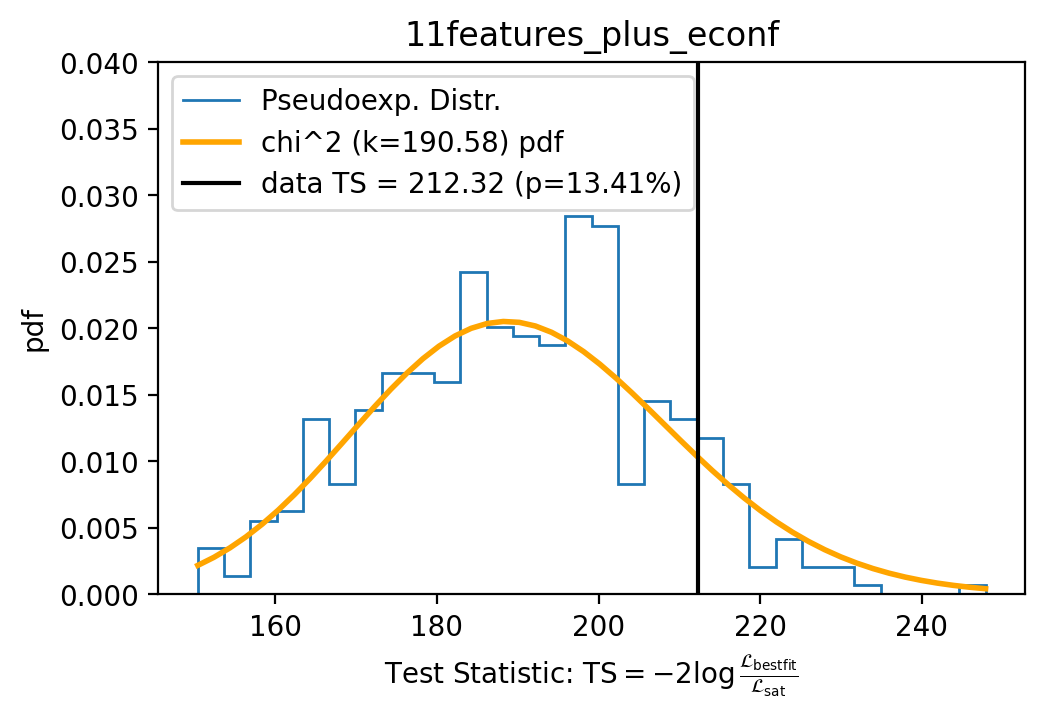

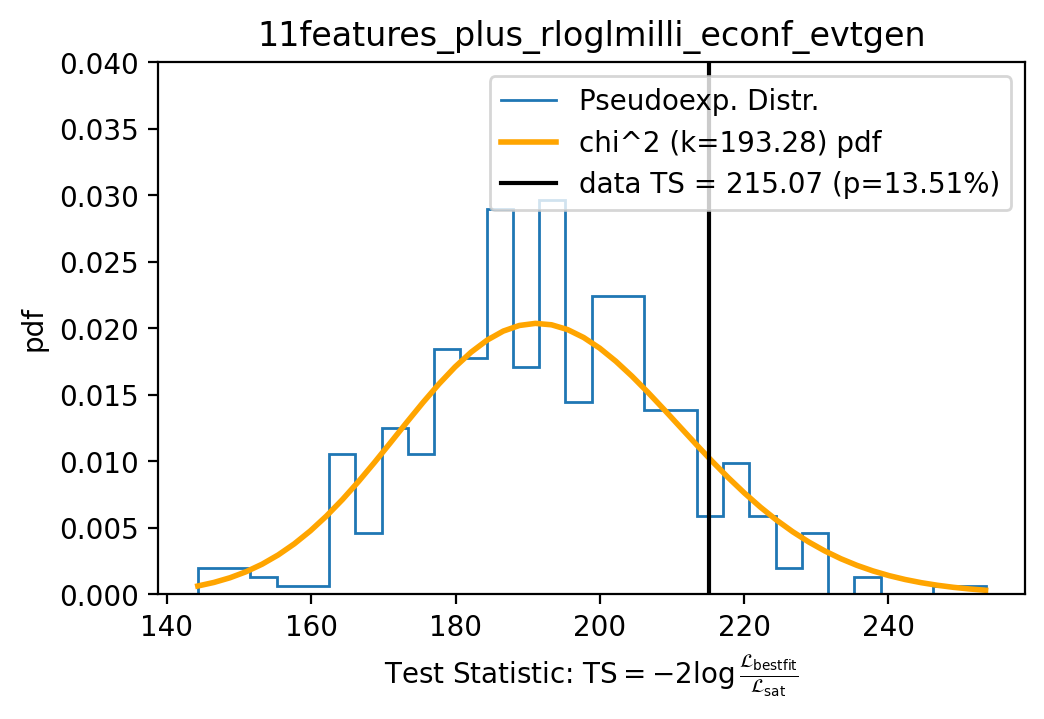

In [33]:
from scipy.stats import chi2

fit_chi2 = True

for name, title in zip(
    names, names
):
    print(name)
    pseudoexp_ts = dfs[name]["combined_ts"]
    data_TS = bestfit_llh_infos[name]["ts"]

    fig, ax = SinglePlot().create(dpi=200)
    ax.set_title(title)
    quantiles = np.quantile(pseudoexp_ts, [0.01, 0.99])
    hist, bins = np.histogram(pseudoexp_ts, bins=30, density=True)

    color = all_hdls[name]["pseudoexp_settings"]["color"]

    ax.stairs(
        hist,
        bins,
        color=color,
        label="Pseudoexp. Distr."
    )

    # # plot quantiles
    # ax.axvline(
    #     quantiles[0],
    #     color=color,
    #     linestyle='--',
    #     label='1% Quantile'
    # )
    # ax.axvline(
    #     quantiles[1],
    #     color=color,
    #     linestyle='--',
    #     label='99% Quantile'
    # )

    if fit_chi2:
        chi2_fit = chi2.fit(pseudoexp_ts, floc=0.0, fscale=1.0)
        rv = chi2(chi2_fit[0])
        x = np.linspace(min(pseudoexp_ts), max(pseudoexp_ts))
        ax.plot(
            x,
            rv.pdf(x),
            color='orange', linewidth=2,
            label=f"chi^2 (k={chi2_fit[0]:.2f}) pdf"
        )

    if data_TS is not None:
        label = f"data TS = {data_TS:.2f}"
        if fit_chi2:
            p = chi2.sf(x=data_TS, df=chi2_fit[0]) * 100
            label += f" (p={p:.2f}%)"
        ax.axvline(data_TS, color="black", linestyle='-', label=label)

    ax.set_xlabel(
        r'Test Statistic: $\mathrm{TS} = -2\log \frac{\mathcal{L}_{\mathrm{bestfit}}}{\mathcal{L}_{\mathrm{sat}}}$'
    )
    ax.set_ylabel("pdf")
    ax.set_ylim(0,0.04)
    plt.legend()
    plt.savefig(
        os.path.join(
            plotting_path,
            f"{name}.png"
        ),
        bbox_inches='tight'
    )
